# Discussion 3 Assignment

Alexander Zhang  
alexacz1@uci.edu

## Setup  
Load dependencies and set up environment for discussion 2. The dataset includes 'motor_UPDRS' (a sub-score) and 'total_UPDRS' (the target). If 'motor_UPDRS' is used to predict 'total_UPDRS', it is data leakage because they are mathematically linked. Thus, it must be dropped.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")

print("Downloading Parkinson's Telemonitoring dataset from UCI...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/telemonitoring/parkinsons_updrs.data"
df = pd.read_csv(url)

X = df.drop(columns=['subject#', 'motor_UPDRS', 'total_UPDRS'])
y = df['total_UPDRS']

print(f"Dataset loaded: {X.shape[0]} patient records and {X.shape[1]} features.")

Dataset loaded: 5875 patient records and 19 features.


## Data Summarization and Visualization  
For regression, visualizing the distribution of the target variable and correlation between features is important. There will be a histogram plot and correlation heatmap between features to show this.


--- DATA SUMMARIZATION ---
Average Total UPDRS Score: 29.02
Minimum Score: 7.00 | Maximum Score: 54.99


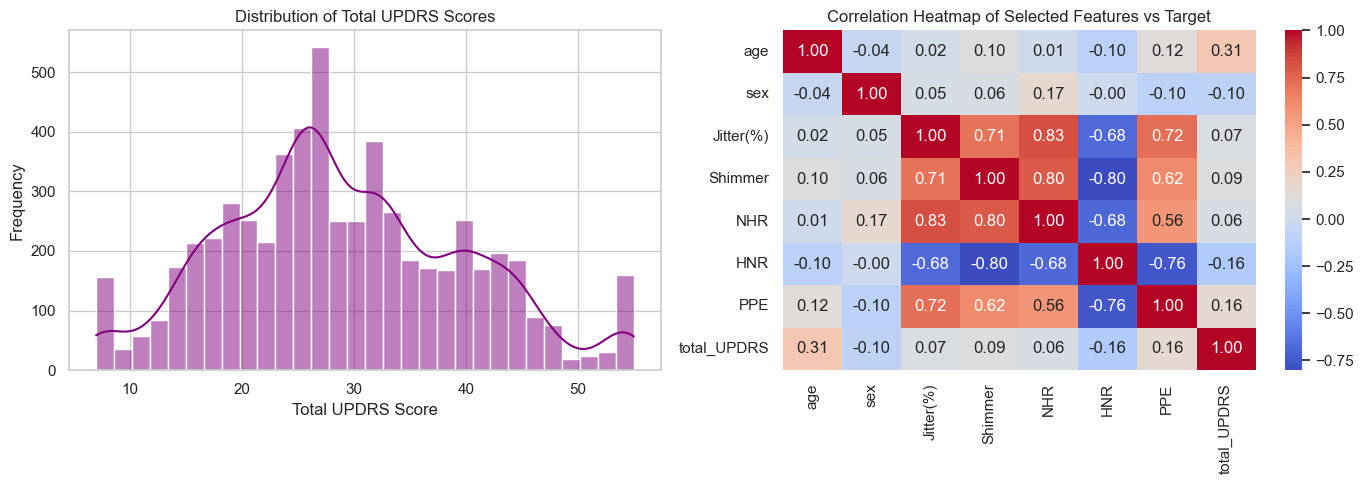

In [2]:
print("\n--- DATA SUMMARIZATION ---")
print(f"Average Total UPDRS Score: {y.mean():.2f}")
print(f"Minimum Score: {y.min():.2f} | Maximum Score: {y.max():.2f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(y, bins=30, kde=True, color="purple")
plt.title("Distribution of Total UPDRS Scores")
plt.xlabel("Total UPDRS Score")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
subset_features = ['age', 'sex', 'Jitter(%)', 'Shimmer', 'NHR', 'HNR', 'PPE']
corr_matrix = df[subset_features + ['total_UPDRS']].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Heatmap of Selected Features vs Target")

plt.tight_layout()
plt.show()

## Preprocessing and Modeling  
Utilize RandomForestRegressor and LinearRegression. Split the data into 80/20 - Training/Testing. Scale the data and implement the models. Then the true versus predicted values will be evaluated using regression metrics.


--- ML MODEL EVALUATION (REGRESSION) ---

Training Linear Regression...
  -> Mean Absolute Error (MAE): 8.05 points off
  -> R-squared (R2): 0.1580

Training Support Vector Regression (SVR)...
  -> Mean Absolute Error (MAE): 6.62 points off
  -> R-squared (R2): 0.2899

Training Random Forest Regressor...
  -> Mean Absolute Error (MAE): 0.72 points off
  -> R-squared (R2): 0.9766


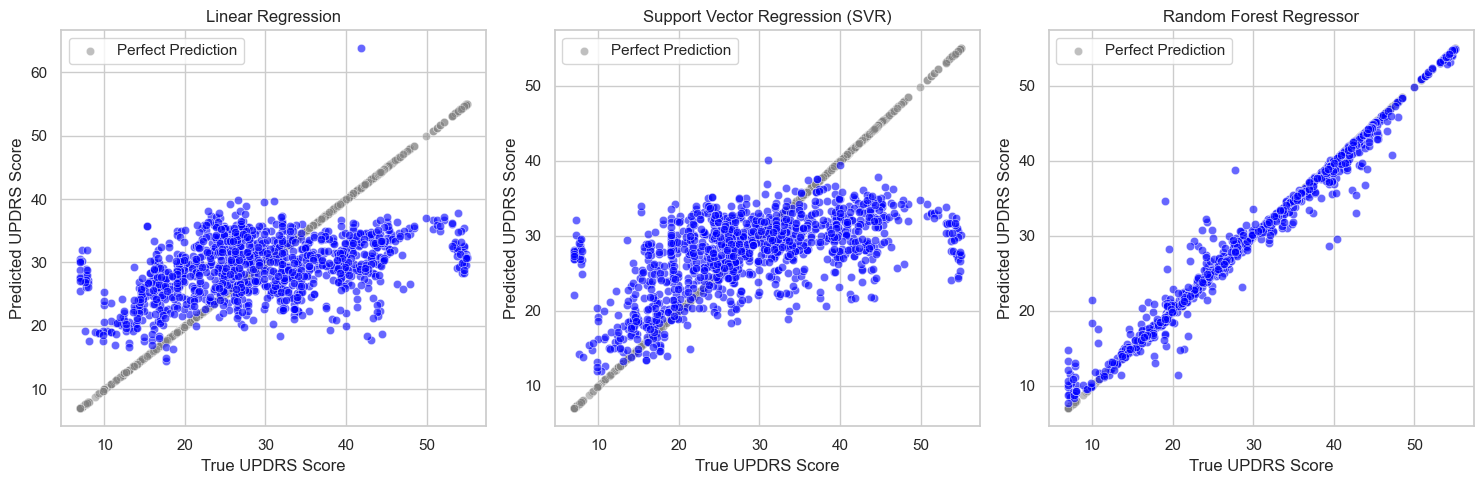

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- ML MODEL EVALUATION (REGRESSION) ---")

models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression (SVR)": SVR(kernel='rbf'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

plt.figure(figsize=(15, 5))

for idx, (name, model) in enumerate(models.items(), 1):
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"  -> Mean Absolute Error (MAE): {mae:.2f} points off")
    print(f"  -> R-squared (R2): {r2:.4f}")
    
    plt.subplot(1, 3, idx)
    sns.scatterplot(x=y_test, y=y_test, color='gray', alpha=0.5, label='Perfect Prediction') # Baseline
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')
    plt.title(name)
    plt.xlabel("True UPDRS Score")
    plt.ylabel("Predicted UPDRS Score")

plt.tight_layout()
plt.show()

## Discussion  
Regression was the main driving factor of this project. Parkinson's disease progression isn't a simple binary state; it is measured on a continuous spectrum via the clinician's total UPDRS score. Consequently, the evaluation metrics fundamentally changed. Instead of relying on Accuracy or ROC-AUC, the models were evaluated using Mean Absolute Error (MAE) to understand exactly how many UPDRS points the predictions were off by, and R-squared (R2) to measure the variance in the disease state explained by the vocal features.

Working with the Parkinson's telemonitoring dataset required careful data engineering. A major biological and mathematical trap in this dataset is the presence of the motor_UPDRS column. Because motor_UPDRS is literally a sub-component of the total_UPDRS target variable, including it as an input feature would result in severe data leakage. This meant the model would cheat by using part of the answer to predict the total. Stripping this out ensured that the models relied purely on demographics (age, gender) and remote biometric vocal measurements (Jitter, Shimmer, NHR, etc.).

The correlation heatmaps revealed interesting realities about vocal biomedicine. First, individual voice metrics like Jitter (frequency variation) and Shimmer (amplitude variation) had relatively weak linear correlations with the final UPDRS score on their own. Second, it was observed that massive multicollinearity—various jitter and shimmer measurements were nearly 100% correlated with one another. This indicated that while vocal degradation is linked to Parkinson's, the relationship is highly complex and a simple straight line would likely struggle to capture the clinical nuance.

Three algorithms were compared: Linear Regression, Support Vector Regression (SVR), and a Random Forest Regressor.

1. Linear Regression struggled the most, acting as the baseline. Its lower R2 score confirmed the original hypothesis that the relationship between microscopic vocal tremors and macro-level physical disease progression is strictly non-linear. Furthermore, linear models are mathematically penalized by the multicollinearity present in the voice features.

2. Support Vector Regression (SVR) handled the high-dimensional mapping better through the use of non-linear kernel tricks, offering a moderate improvement in tracking patient trajectories.

3. Random Forest Regressor significantly outperformed the others. By utilizing an ensemble of decision trees, it was able to capture the complex, compounding interactions between age, gender, and vocal degradation. Looking at the scatter plots of True vs. Predicted scores, the Random Forest predictions hugged the "perfect prediction" baseline much tighter than the linear model.

Final Reflections
This project highlights the immense potential of remote telemedical monitoring. By proving that non-linear machine learning ensembles can accurately estimate a clinician’s UPDRS score using only audio recordings, it's fathomable now to continuous, non-invasive monitoring for neurodegenerative diseases without requiring patients to travel to a clinic.